**We are Making  a model that predicts the house prices**

*we importing these libararies for dataFrame creation and caluclations purpose*

In [1]:
import numpy as np
import pandas as pd

*we importing these libararies for DataFrame Visulization purpose*

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

*we importing these libararies for Machine learning algorithms purpose*

In [31]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\shiva\anaconda3\envs\ML_Learning\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 


In [4]:
#Loading Housing DataSet
Housing_data = pd.read_csv("Housing.csv")
Housing_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


**Importants Things that we should to ask our DataSet When we see it for first time**

In [5]:
# Size of data How big our DataSet is
Housing_data.shape

# the below is the size of data means 21 features() and 21613 rows

(21613, 21)

In [7]:
# how ours data looks like means sample of data
Housing_data.head() # one way ita gives first 5 rows of data
Housing_data.sample(10) # it gives the randomaly data according to our input

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2351,2024059084,20150313T000000,625000.0,4,2.75,2290,21486,1.0,0,2,...,7,2290,0,1963,0,98006,47.5515,-122.189,2540,15936
12984,9320900610,20141231T000000,146000.0,3,1.00,900,4770,1.0,0,0,...,6,900,0,1969,2009,98023,47.3038,-122.362,900,3480
20907,8562780540,20141222T000000,325000.0,2,2.25,1150,711,2.0,0,0,...,7,1150,0,2013,0,98027,47.5323,-122.070,1150,748
11362,7701960990,20140616T000000,862000.0,4,2.50,3190,14565,2.0,0,0,...,11,3190,0,1990,0,98077,47.7130,-122.072,3420,20475
19616,1446400564,20140507T000000,185000.0,4,1.00,1490,6600,1.0,0,0,...,7,1490,0,1969,0,98168,47.4835,-122.332,1280,6600
17927,3330501645,20150223T000000,260000.0,3,1.00,1150,3090,1.0,0,0,...,6,1150,0,1910,0,98118,47.5506,-122.276,1150,5664
5375,4359100050,20150330T000000,244000.0,3,1.50,1360,9625,1.0,0,0,...,7,1360,0,1963,0,98030,47.3799,-122.211,1890,9625
8639,259000100,20141007T000000,430000.0,3,1.75,1610,7900,1.0,0,0,...,8,1310,300,1960,0,98177,47.7588,-122.360,2210,7700
20095,8562780490,20150223T000000,335000.0,3,2.50,1150,683,2.0,0,0,...,7,1150,0,2013,0,98027,47.5323,-122.071,1150,755
18101,6648150040,20140513T000000,1680000.0,5,3.25,4860,23723,2.0,0,2,...,11,3820,1040,1989,0,98040,47.5767,-122.215,4040,13860


In [8]:
# Data types of each features(columns)
Housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [11]:
# we are finding that Is there any missing value in the data
Housing_data.isna() # one way it gives all the dataSet if there is any then give true else false
Housing_data.isnull() # both are same
Housing_data.isna().sum() # it giveas the sum of all null values if present in the data set

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [14]:
# finding the duplicates values in our dataSet
Housing_data.duplicated("price") # through this way we can givae each feature to find the duplicate
Housing_data.duplicated().sum() # it gives the total sum of duplicated values

np.int64(0)

In [15]:
# now we finding that how  mathematically data looks like
Housing_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


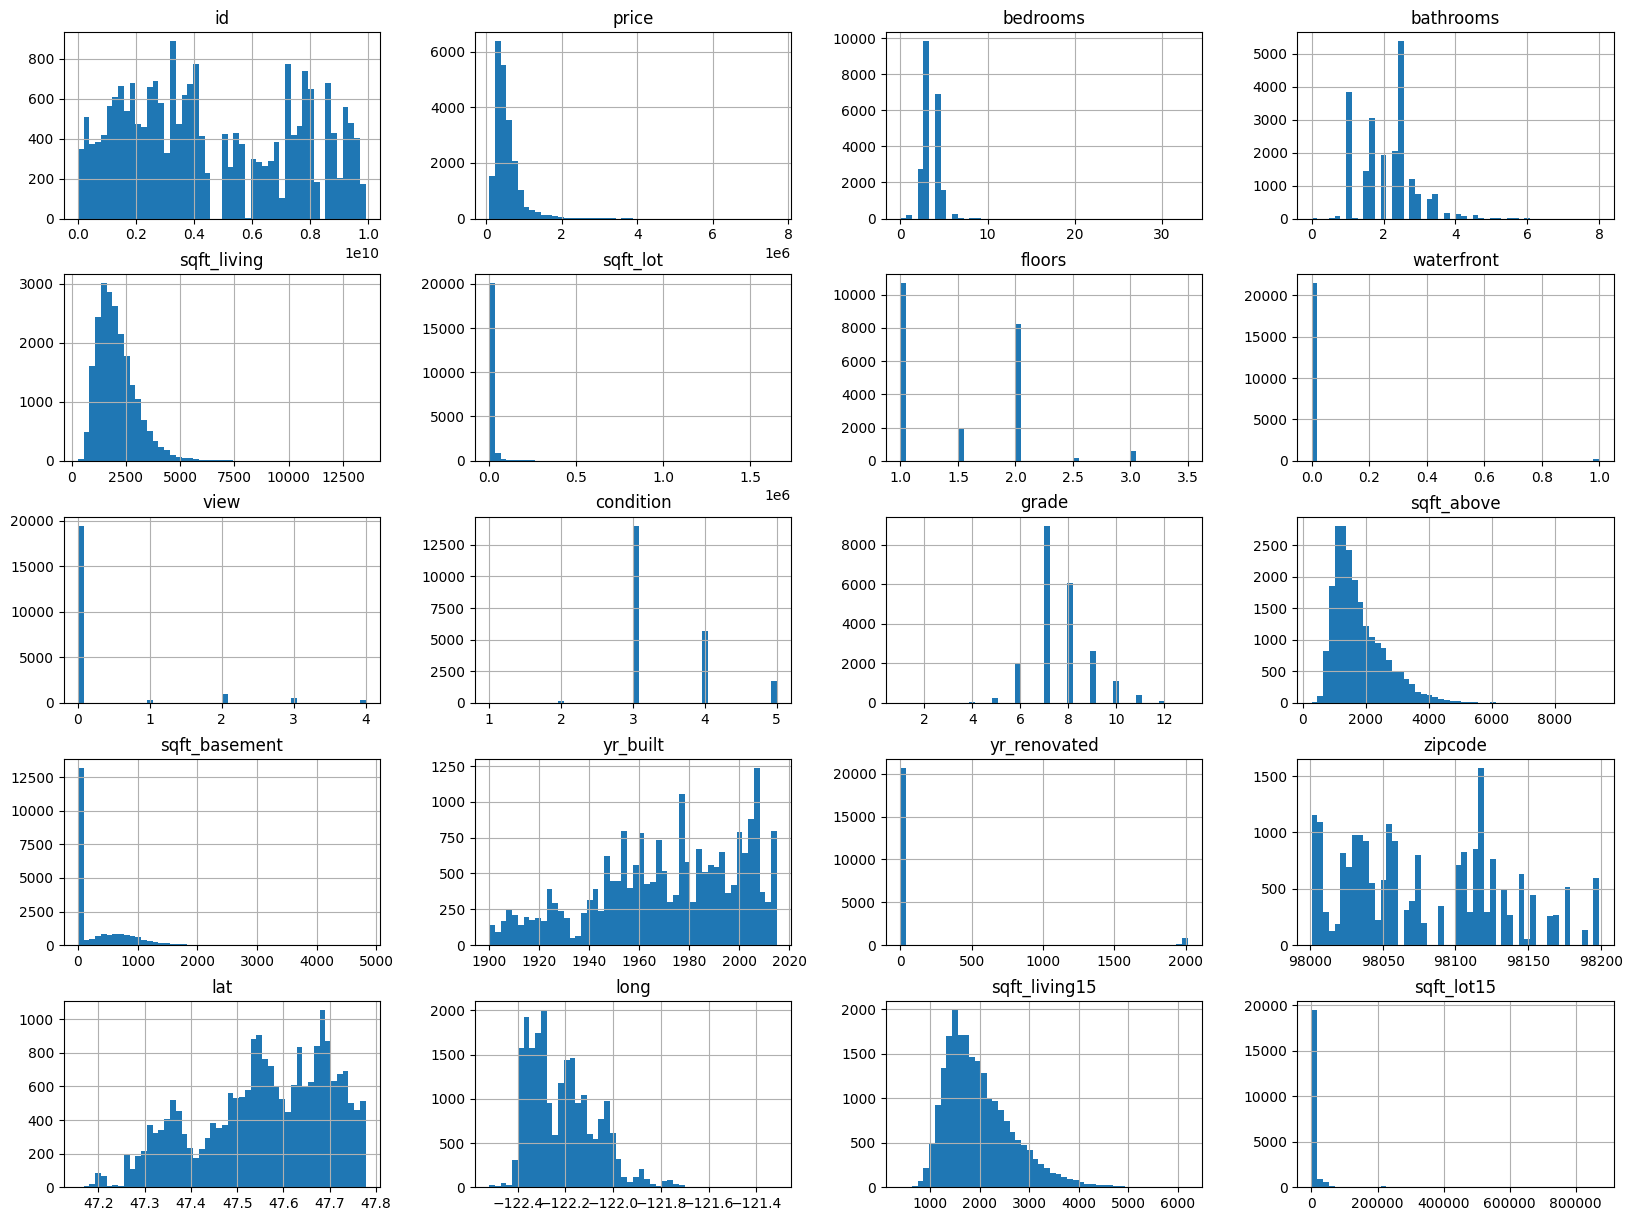

In [23]:
# another way to feel our data using plotting
Housing_data.hist(bins=50,figsize=(20,15))
plt.show()

In [84]:
# now we are checking that how our each features are correlated to each other
Housing_data.corr() # we can't perform corr method on categorical or other than numerical data type

ValueError: could not convert string to float: '20141013T000000'

*Creating a test set*

**AAM ZINDAGI**

In [24]:
# we createad a funcation to split our data into two parts
def split_train_test(data,test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [33]:
# we called the function and pass our dataSet
train_set1 ,test_set1 = split_train_test(Housing_data,0.2)

In [34]:
print("size of train data:",len(train_set1))
print("size of test data:",len(test_set1))

size of train data: 17291
size of test data: 4322


*The major problem of spliting data using manual or function that :-- if you run the program again, it will generate a different test set! Over time, you (or your Machine Learning algorithms) will get to see the whole dataset*

**MENTOS ZINDAGI**
*We are spiliting our dataSet with the healp of scikit-learn*

In [32]:
# we are importing train_test_split method from scikit-learn
from sklearn.model_selection import train_test_split


In [35]:
train_set ,test_set = train_test_split(Housing_data,test_size=0.2,random_state=42)

# random_state : int, RandomState instance or None, default=None
# Controls the shuffling applied to the data before applying the split. 

In [36]:
print("size of train data:",len(train_set))
print("size of test data:",len(test_set))

size of train data: 17290
size of test data: 4323


In [40]:
train_set

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6325,5467910190,20140527T000000,325000.0,3,1.75,1780,13095,1.0,0,0,...,9,1780,0,1983,0,98042,47.3670,-122.152,2750,13095
13473,9331800580,20150310T000000,257000.0,2,1.00,1000,3700,1.0,0,0,...,6,800,200,1929,0,98118,47.5520,-122.290,1270,5000
17614,2407000405,20150226T000000,228500.0,3,1.00,1080,7486,1.5,0,0,...,6,990,90,1942,0,98146,47.4838,-122.335,1170,7800
16970,5466700290,20150108T000000,288000.0,3,2.25,2090,7500,1.0,0,0,...,7,1280,810,1977,0,98031,47.3951,-122.172,1800,7350
20868,3026059361,20150417T000000,479000.0,2,2.50,1741,1439,2.0,0,0,...,8,1446,295,2007,0,98034,47.7043,-122.209,2090,10454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,5272200045,20141113T000000,378000.0,3,1.50,1000,6914,1.0,0,0,...,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
21575,9578500790,20141111T000000,399950.0,3,2.50,3087,5002,2.0,0,0,...,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
5390,7202350480,20140930T000000,575000.0,3,2.50,2120,4780,2.0,0,0,...,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
860,1723049033,20140620T000000,245000.0,1,0.75,380,15000,1.0,0,0,...,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [41]:
test_set

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
735,2591820310,20141006T000000,365000.0,4,2.25,2070,8893,2.0,0,0,...,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
2830,7974200820,20140821T000000,865000.0,5,3.00,2900,6730,1.0,0,0,...,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
4106,7701450110,20140815T000000,1038000.0,4,2.50,3770,10893,2.0,0,2,...,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
16218,9522300010,20150331T000000,1490000.0,3,3.50,4560,14608,2.0,0,2,...,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
19964,9510861140,20140714T000000,711000.0,3,2.50,2550,5376,2.0,0,0,...,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13674,6163900333,20141110T000000,338000.0,3,1.75,1250,7710,1.0,0,0,...,7,1250,0,1947,0,98155,47.7623,-122.317,1340,7710
20377,3528960020,20140708T000000,673000.0,3,2.75,2830,3496,2.0,0,0,...,8,2830,0,2012,0,98029,47.5606,-122.011,2160,3501
8805,1687000220,20141016T000000,285000.0,4,2.50,2434,4400,2.0,0,0,...,8,2434,0,2007,0,98001,47.2874,-122.283,2434,4400
10168,4141400030,20141201T000000,605000.0,4,1.75,2250,10108,1.0,0,0,...,8,2250,0,1967,0,98008,47.5922,-122.118,2050,9750


<Axes: xlabel='long', ylabel='lat'>

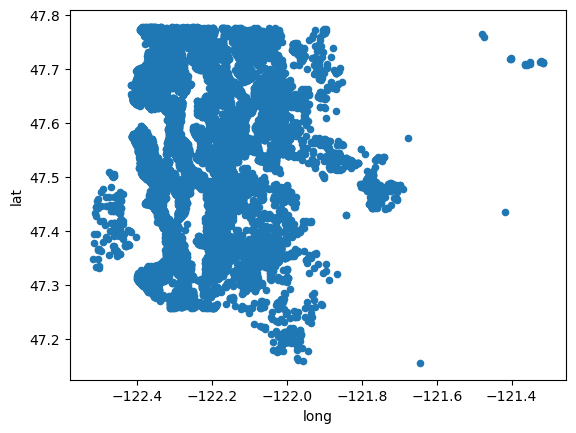

In [44]:
# Visualizing geographical data
Housing_data.plot(kind='scatter',x="long",y="lat")

<Axes: xlabel='long', ylabel='lat'>

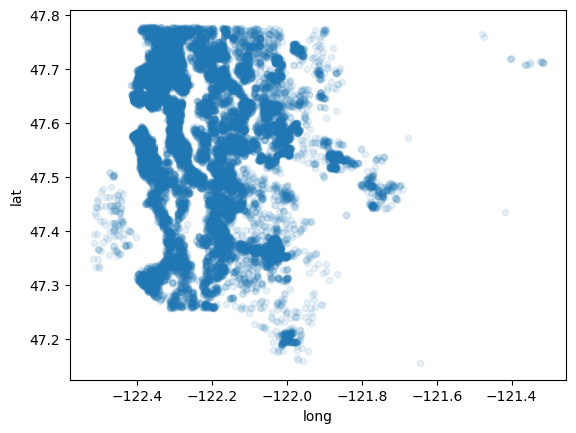

In [45]:
Housing_data.plot(kind='scatter',x="long",y="lat",alpha=0.1)

In [47]:
Housing_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [57]:
housing_train = train_set.drop("price",axis=1) # we drop the label table from train data
housing_labels_train =train_set["price"].copy() # we create a new dataFrame from labels data

In [58]:
housing_train

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6325,5467910190,20140527T000000,3,1.75,1780,13095,1.0,0,0,4,9,1780,0,1983,0,98042,47.3670,-122.152,2750,13095
13473,9331800580,20150310T000000,2,1.00,1000,3700,1.0,0,0,3,6,800,200,1929,0,98118,47.5520,-122.290,1270,5000
17614,2407000405,20150226T000000,3,1.00,1080,7486,1.5,0,0,3,6,990,90,1942,0,98146,47.4838,-122.335,1170,7800
16970,5466700290,20150108T000000,3,2.25,2090,7500,1.0,0,0,4,7,1280,810,1977,0,98031,47.3951,-122.172,1800,7350
20868,3026059361,20150417T000000,2,2.50,1741,1439,2.0,0,0,3,8,1446,295,2007,0,98034,47.7043,-122.209,2090,10454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,5272200045,20141113T000000,3,1.50,1000,6914,1.0,0,0,3,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
21575,9578500790,20141111T000000,3,2.50,3087,5002,2.0,0,0,3,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
5390,7202350480,20140930T000000,3,2.50,2120,4780,2.0,0,0,3,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
860,1723049033,20140620T000000,1,0.75,380,15000,1.0,0,0,3,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [55]:
housing_labels_train

6325     325000.0
13473    257000.0
17614    228500.0
16970    288000.0
20868    479000.0
           ...   
11964    378000.0
21575    399950.0
5390     575000.0
860      245000.0
15795    315000.0
Name: price, Length: 17290, dtype: float64

In [63]:
housing_test = test_set.drop("price",axis=1) # we drop the label table from train data
housing_labels_test =test_set["price"].copy() # we create a new dataFrame from labels data

In [64]:
housing_test

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
735,2591820310,20141006T000000,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
2830,7974200820,20140821T000000,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
4106,7701450110,20140815T000000,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
16218,9522300010,20150331T000000,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
19964,9510861140,20140714T000000,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13674,6163900333,20141110T000000,3,1.75,1250,7710,1.0,0,0,4,7,1250,0,1947,0,98155,47.7623,-122.317,1340,7710
20377,3528960020,20140708T000000,3,2.75,2830,3496,2.0,0,0,3,8,2830,0,2012,0,98029,47.5606,-122.011,2160,3501
8805,1687000220,20141016T000000,4,2.50,2434,4400,2.0,0,0,3,8,2434,0,2007,0,98001,47.2874,-122.283,2434,4400
10168,4141400030,20141201T000000,4,1.75,2250,10108,1.0,0,0,4,8,2250,0,1967,0,98008,47.5922,-122.118,2050,9750


In [65]:
housing_labels_test

735       365000.0
2830      865000.0
4106     1038000.0
16218    1490000.0
19964     711000.0
           ...    
13674     338000.0
20377     673000.0
8805      285000.0
10168     605000.0
2522      356500.0
Name: price, Length: 4323, dtype: float64

**Handling Categorical Data**

**Feature Selection :- Droping uncessary features**

In [79]:
housing_train = housing_train.drop("date",axis=1) # we dropped the id from traing data
housing_train = housing_train.drop("date",axis=1) # we dropped the date from traing data data

In [80]:
housing_train

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6325,3,1.75,1780,13095,1.0,0,0,4,9,1780,0,1983,0,98042,47.3670,-122.152,2750,13095
13473,2,1.00,1000,3700,1.0,0,0,3,6,800,200,1929,0,98118,47.5520,-122.290,1270,5000
17614,3,1.00,1080,7486,1.5,0,0,3,6,990,90,1942,0,98146,47.4838,-122.335,1170,7800
16970,3,2.25,2090,7500,1.0,0,0,4,7,1280,810,1977,0,98031,47.3951,-122.172,1800,7350
20868,2,2.50,1741,1439,2.0,0,0,3,8,1446,295,2007,0,98034,47.7043,-122.209,2090,10454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,3,1.50,1000,6914,1.0,0,0,3,7,1000,0,1947,0,98125,47.7144,-122.319,1000,6947
21575,3,2.50,3087,5002,2.0,0,0,3,8,3087,0,2014,0,98023,47.2974,-122.349,2927,5183
5390,3,2.50,2120,4780,2.0,0,0,3,7,2120,0,2004,0,98053,47.6810,-122.032,1690,2650
860,1,0.75,380,15000,1.0,0,0,3,5,380,0,1963,0,98168,47.4810,-122.323,1170,15000


In [82]:
housing_test= housing_test.drop("id",axis=1) # we dropped the id from testing data data
housing_test=housing_test.drop("date",axis=1) # we dropped the date from testing data data

In [83]:
housing_test

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
735,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
2830,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
4106,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
16218,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
19964,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13674,3,1.75,1250,7710,1.0,0,0,4,7,1250,0,1947,0,98155,47.7623,-122.317,1340,7710
20377,3,2.75,2830,3496,2.0,0,0,3,8,2830,0,2012,0,98029,47.5606,-122.011,2160,3501
8805,4,2.50,2434,4400,2.0,0,0,3,8,2434,0,2007,0,98001,47.2874,-122.283,2434,4400
10168,4,1.75,2250,10108,1.0,0,0,4,8,2250,0,1967,0,98008,47.5922,-122.118,2050,9750


In [87]:
# we are finding the correlation between our train,test feature data sets
housing_test.corr()
housing_train.corr()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
bedrooms,1.000000,0.515327,0.575076,0.031067,0.173009,-0.010038,0.070191,0.028222,0.353527,0.474404,0.300830,0.148849,0.020927,-0.152816,-0.013299,0.126022,0.386246,0.023640
bathrooms,0.515327,1.000000,0.752745,0.086344,0.504126,0.063145,0.179657,-0.124764,0.664407,0.683303,0.277038,0.505649,0.051332,-0.202922,0.026761,0.221848,0.563438,0.079958
sqft_living,0.575076,0.752745,1.000000,0.176264,0.348917,0.095543,0.275554,-0.056163,0.760652,0.875820,0.427831,0.315848,0.054880,-0.203540,0.053920,0.242701,0.754904,0.174895
sqft_lot,0.031067,0.086344,0.176264,1.000000,-0.004670,0.027354,0.061524,-0.010531,0.116535,0.187159,0.014017,0.051956,0.015425,-0.135121,-0.078886,0.240164,0.151801,0.734932
floors,0.173009,0.504126,0.348917,-0.004670,1.000000,0.018441,0.027260,-0.268652,0.457274,0.518214,-0.248916,0.495168,0.005480,-0.054722,0.054014,0.121500,0.271551,-0.012202
waterfront,-0.010038,0.063145,0.095543,0.027354,0.018441,1.000000,0.390616,0.017313,0.070820,0.063283,0.079072,-0.030817,0.088378,0.026815,-0.018784,-0.043843,0.075609,0.032785
view,0.070191,0.179657,0.275554,0.061524,0.027260,0.390616,1.000000,0.048571,0.244440,0.159612,0.270938,-0.058776,0.100026,0.084540,0.005750,-0.086336,0.276378,0.063760
condition,0.028222,-0.124764,-0.056163,-0.010531,-0.268652,0.017313,0.048571,1.000000,-0.143680,-0.158199,0.180120,-0.361492,-0.061802,0.003919,-0.018660,-0.109123,-0.094194,-0.006322
grade,0.353527,0.664407,0.760652,0.116535,0.457274,0.070820,0.244440,-0.143680,1.000000,0.752990,0.162885,0.447234,0.013731,-0.182515,0.118808,0.197489,0.707253,0.114337
sqft_above,0.474404,0.683303,0.875820,0.187159,0.518214,0.063283,0.159612,-0.158199,0.752990,1.000000,-0.061533,0.423524,0.021762,-0.264291,-0.000946,0.347579,0.729165,0.187337


In [88]:
Housing_data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


**Feature Transform**

**Training Our Model**

**Model Selection**
model-1 Linear Regression

In [89]:
from sklearn.linear_model import LinearRegression

In [90]:
lin_reg = LinearRegression()

In [91]:
lin_reg.fit(housing_train,housing_labels_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Validating our model

In [92]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = lin_reg.predict(housing_test)

mse = mean_squared_error(housing_labels_test, predictions)
r2 = r2_score(housing_labels_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 45173027114.565994
R2 Score: 0.7011905706891229


Model-2 Decision Tree Regression

In [93]:
from sklearn.tree import DecisionTreeRegressor


In [96]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_train,housing_labels_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

Validating our model 

In [97]:
housing_predictions = tree_reg.predict(housing_test)

In [98]:
tree_sme = mean_squared_error(housing_labels_test,housing_predictions)

In [99]:
tree_rmse = np.sqrt(tree_sme)

In [100]:
tree_sme

42229586466.383064

In [101]:
tree_rmse

np.float64(205498.38555663417)

In [102]:
housing_labels_test


735       365000.0
2830      865000.0
4106     1038000.0
16218    1490000.0
19964     711000.0
           ...    
13674     338000.0
20377     673000.0
8805      285000.0
10168     605000.0
2522      356500.0
Name: price, Length: 4323, dtype: float64

*Checking some sample data from the test dataset with both models*

In [107]:
prediction = lin_reg.predict(housing_test.loc[[8805]])
print(prediction)

[423104.75545082]


In [108]:
prediction = tree_reg.predict(housing_test.loc[[8805]])
print(prediction)

[280000.]


*We are giving random data's to predict the model*

In [109]:
import numpy as np

# Generate random sample data based on the features in housing_train
# Using approximate min/max from the dataset for realism
random_data = pd.DataFrame({
    'bedrooms': [np.random.randint(1, 6)],
    'bathrooms': [np.random.uniform(1, 4)],
    'sqft_living': [np.random.randint(500, 5000)],
    'sqft_lot': [np.random.randint(1000, 50000)],
    'floors': [np.random.uniform(1, 3)],
    'waterfront': [np.random.choice([0, 1])],
    'view': [np.random.randint(0, 5)],
    'condition': [np.random.randint(1, 6)],
    'grade': [np.random.randint(1, 13)],
    'sqft_above': [np.random.randint(500, 4000)],
    'sqft_basement': [np.random.randint(0, 2000)],
    'yr_built': [np.random.randint(1900, 2020)],
    'yr_renovated': [np.random.choice([0, np.random.randint(1990, 2020)])],
    'zipcode': [np.random.randint(98000, 98200)],
    'lat': [np.random.uniform(47.1, 47.8)],
    'long': [np.random.uniform(-122.5, -121.5)],
    'sqft_living15': [np.random.randint(500, 4000)],
    'sqft_lot15': [np.random.randint(1000, 50000)]
})

print("Random sample data:")
print(random_data)

# Predict using Linear Regression model
lin_pred = lin_reg.predict(random_data)
print(f"\nLinear Regression Prediction: ${lin_pred[0]:.2f}")

# Predict using Decision Tree model
tree_pred = tree_reg.predict(random_data)
print(f"Decision Tree Prediction: ${tree_pred[0]:.2f}")

Random sample data:
   bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront  view  \
0         1   1.680771         2455     36892  2.228711           0     4   

   condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
0          3      8         625            178      1958          2000   

   zipcode        lat        long  sqft_living15  sqft_lot15  
0    98155  47.185536 -121.955251           1773        5646  

Linear Regression Prediction: $539430.75
Decision Tree Prediction: $468000.00


**CONCLUSION OF THE PROJECT**

We are just trying to build a model that predict the price of house based on their specifications  so we successfully builded that model 
but it is not accurate or optimized due to some steps are left or some EDA,dataprocessing ,encoding,etc... But our main goal to build a model that we done.